# Data Preprocessing for Machine Learning: A Hands-On Project

This notebook walks through the preprocessing decisions that matter most before any model gets trained: encoding categories correctly, scaling numbers correctly, and not leaking information from test data into training.

The dataset is synthetic retail data designed to have a few specific problems on purpose, so you can see what they look like and how to fix them:

- `annual_income` has 50 outlier rows (high earners) mixed into 950 normal ones
- `purchase_amount` is right-skewed, typical of spending data
- `size` has a real order (S < M < L < XL); `product_category` and `region` don't
- `is_returned` is the target, and it's worth knowing upfront: in this dataset it's pure random noise, unrelated to any other column. That's intentional, and it becomes useful later when we talk about leakage.

Each section builds on the last. By the end you'll have a saved, reusable preprocessing pipeline and a clear answer to "why does the train/test split happen before scaling, not after?"


In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "customer_age": np.random.randint(18, 75, n),
    "annual_income": np.concatenate([
        np.random.normal(60000, 15000, 950),
        np.random.normal(250000, 30000, 50)
    ]),
    "purchase_amount": np.random.exponential(80, n),
    "product_category": np.random.choice(
        ["Electronics", "Clothing", "Food", "Books", "Sports"], n
    ),
    "size": np.random.choice(
        ["S", "M", "L", "XL"], n,
        p=[0.2, 0.35, 0.3, 0.15]
    ),
    "region": np.random.choice(
        ["North", "South", "East", "West"], n
    ),
    "is_returned": np.random.binomial(1, 0.15, n)
})

df.to_csv("day01_retail.csv", index=False)
print(df.shape)

(1000, 7)


## Section 1: Initial Data Exploration

Before touching any preprocessing tool, you need to know what you're working with. Skipping this step is how people end up scaling a column that's actually a category, or one-hot encoding something that should stay numeric.

**What to check, and why:**

- **Shape** — how many rows and columns. Cheap sanity check; if this doesn't match what you expect, stop here.
- **Dtypes** — pandas will sometimes read numbers as strings or vice versa. You need to know this before encoding/scaling decisions.
- **Missing values** — preprocessing tools handle missing data differently (some error out, some silently break). Know your nulls before you pick a tool.
- **Summary statistics** — mean vs median tells you about skew at a glance. A huge gap between the two is a signal you'll need before picking a scaler.
- **Value counts on categoricals** — tells you cardinality (how many unique values) and class balance, both of which affect encoding choice.


In [4]:
df.shape

(1000, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_age      1000 non-null   int32  
 1   annual_income     1000 non-null   float64
 2   purchase_amount   1000 non-null   float64
 3   product_category  1000 non-null   str    
 4   size              1000 non-null   str    
 5   region            1000 non-null   str    
 6   is_returned       1000 non-null   int32  
dtypes: float64(2), int32(2), str(3)
memory usage: 47.0 KB


Nothing here is missing, and the dtypes are what you'd expect: numeric columns came in as `int64`/`float64`, categorical columns as `object` (strings). If `customer_age` had shown up as `object`, that would mean some rows have a string ("twenty-five" or a stray comma) breaking the numeric read, and that needs fixing before any scaler touches it.

In [6]:
df.isnull().sum()

customer_age        0
annual_income       0
purchase_amount     0
product_category    0
size                0
region              0
is_returned         0
dtype: int64

In [24]:
df.describe(include="all")

,customer_age,annual_income,purchase_amount,product_category,size,region,is_returned
count,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.000000
unique,NaN,NaN,NaN,5,4,4,NaN
top,NaN,NaN,NaN,Food,M,South,NaN
freq,NaN,NaN,NaN,213,347,286,NaN
mean,46.247000,70399.469172,79.124265,NaN,NaN,NaN,0.154000
std,16.288072,45771.526816,78.721177,NaN,NaN,NaN,0.361129
min,18.000000,16556.169327,0.010776,NaN,NaN,NaN,0.000000
25%,33.000000,51234.612502,23.912122,NaN,NaN,NaN,0.000000
50%,46.000000,61266.553326,54.906167,NaN,NaN,NaN,0.000000
75%,60.250000,72467.011542,110.716995,NaN,NaN,NaN,0.000000


This is the cell that flags the outlier problem. Look at `annual_income`: the median (50th percentile) is **61,266**, but the mean is **70,399**, and the max is **314,950** — over 4x the 75th percentile. That gap between mean and median is the tell. A mean pulled well above the median means a handful of large values are dragging the average up, exactly what you'd expect from the 50 high earners mixed into the data.

`purchase_amount` shows the same pattern at a smaller scale: median 54.9, mean 79.1, max 512.4. Right-skewed, as expected from an exponential distribution.

`customer_age` looks boring by comparison, mean and median both sit around 46, no red flags. Boring is good here; it means you probably don't need a robust scaler for that column specifically.

In [8]:
df['size'].value_counts()

size
M     347
L     292
S     224
XL    137
Name: count, dtype: int64

In [9]:
df['product_category'].value_counts()

product_category
Food           213
Sports         209
Electronics    208
Books          185
Clothing       185
Name: count, dtype: int64

In [10]:
df['region'].value_counts()

region
South    286
North    256
West     245
East     213
Name: count, dtype: int64

In [11]:
df['is_returned'].value_counts()

is_returned
0    846
1    154
Name: count, dtype: int64

A few things worth noticing:

`size` has four categories, and they have a built-in order: S is smaller than M, M is smaller than L, and so on. That ordering is information a model could use, if you encode it in a way that preserves it.

`product_category` and `region` also have a handful of categories, but no order. Food isn't "more" than Sports, and North isn't "less" than South. Treating these as ordered would invent a relationship that doesn't exist.

`is_returned` is imbalanced: about 15% of rows are returns. That's mild imbalance, not severe, but it's exactly why the train/test split later uses `stratify=y` — you want both splits to keep roughly the same 85/15 ratio.

**Common mistake:** people sometimes run `.describe()` and stop there, without checking `.value_counts()` on the categorical columns. `.describe()` by default only summarizes numeric columns, so you'd never spot that `size` has an implicit order if you skip this step.

**Reflection:** Looking at the income statistics, why might the mean be a worse summary of "typical" annual income than the median, for this dataset specifically?

## Section 2: Understanding Encoding

Models do arithmetic. They multiply numbers by weights, add things up, take gradients. A string like `"Electronics"` can't enter any of that math, so before a categorical column reaches a model, it has to become numbers somehow. The *how* matters more than people expect.

**Ordinal vs nominal, the short version:**

A feature is **ordinal** if its categories have a real, meaningful order, and the distance between adjacent categories carries information (or at least a consistent direction). `size` (S, M, L, XL) is ordinal: there's an agreed-upon ranking, and "L is bigger than M" is true regardless of who's asking.

A feature is **nominal** if the categories are just labels with no inherent order. `product_category` (Electronics, Clothing, Food, Books, Sports) is nominal: there's no sense in which Electronics comes "before" Food. You could list them alphabetically, by popularity, by your mood that morning, none of those orderings means anything to a model trying to learn from the data.

**Why this distinction matters for encoding:** if you assign numbers 0, 1, 2, 3, 4 to five nominal categories, you've just told the model "Sports (4) is four units away from Books (0)" — a relationship you invented, not one that exists. Linear models will pick up on that fake distance. Tree-based models are a bit more robust to it but still split on thresholds that imply ordering ("category <= 2"), which makes no sense for unordered labels.

**Why LabelEncoder is for targets, not features:** `LabelEncoder` is built to turn a 1-D array of class labels (your `y`) into integers 0 to n_classes-1. It has no concept of "this column is one of many features," and it will happily assign arbitrary integers to a nominal feature column, creating the exact fake-ordering problem above. Scikit-learn's own docs note this; `OrdinalEncoder` is the feature-column equivalent when you do want integer codes (e.g., for tree models, or genuinely ordinal data) and `OneHotEncoder` is what you want when there's no order to encode.


**Planning the encoding for our three categorical columns:**

| Column | Type | Encoding Choice | Justification |
|---|---|---|---|
| `size` | Ordinal | `OrdinalEncoder` with explicit category order `[S, M, L, XL]` | Preserves the real ranking; a linear model can learn "bigger size → some effect" as a single coefficient instead of four separate dummy weights. |
| `product_category` | Nominal | `OneHotEncoder` | No order exists, so one column per category avoids inventing a fake distance between, say, Books and Sports. |
| `region` | Nominal | `OneHotEncoder` | Same reasoning as `product_category`: North/South/East/West aren't on a scale. |

Now let's see what goes wrong if you ignore this table.

### Demonstration 1: the wrong way — OrdinalEncoder on a nominal column

Watch what happens when `OrdinalEncoder` is applied to `product_category` without specifying that there's no real order (because there isn't one to specify).

In [12]:
from sklearn.preprocessing import OrdinalEncoder

# INCORRECT: applying OrdinalEncoder to a nominal column
oe_wrong = OrdinalEncoder()
encoded_wrong = oe_wrong.fit_transform(df[['product_category']])

print("Category order scikit-learn picked (alphabetical, by default):")
print(oe_wrong.categories_)
print()
print("First 10 encoded values:", encoded_wrong[:10].ravel())
print("First 10 original values:", df['product_category'][:10].values)

Category order scikit-learn picked (alphabetical, by default):
[array(['Books', 'Clothing', 'Electronics', 'Food', 'Sports'], dtype=object)]

First 10 encoded values: [4. 0. 4. 3. 3. 4. 3. 0. 1. 3.]
First 10 original values: <StringArray>
[  'Sports',    'Books',   'Sports',     'Food',     'Food',   'Sports',
     'Food',    'Books', 'Clothing',     'Food']
Length: 10, dtype: str


Look at what `OrdinalEncoder` did by default: it sorted the categories **alphabetically** and assigned 0, 1, 2, 3, 4. So now "Sports" = 4 and "Books" = 0, and a linear model reading this column will treat the gap between Books and Sports as four times the gap between Books and Clothing. There's no reason that should be true; alphabetical order is an artifact of the English alphabet, not a property of retail categories. If you'd loaded the data in a language where these words sort differently, you'd get a completely different — and equally meaningless — set of relationships.

This is the concrete version of "using OrdinalEncoder on `product_category` would create false relationships": the false relationship is the implied distance between category codes, and it's invisible unless you go looking for it like we just did.

### Demonstration 2: the correct way — OrdinalEncoder on a genuinely ordinal column

`size` actually has an order, so here `OrdinalEncoder` is the right tool, as long as you tell it what the order is (otherwise it'll default to alphabetical again, and alphabetically "L" < "M" < "S" < "XL", which is wrong).

In [13]:
# CORRECT: OrdinalEncoder on size, with the real order specified
size_order = [['S', 'M', 'L', 'XL']]
oe_correct = OrdinalEncoder(categories=size_order)
encoded_size = oe_correct.fit_transform(df[['size']])

print("First 10 encoded sizes:", encoded_size[:10].ravel())
print("First 10 original sizes:", df['size'][:10].values)

First 10 encoded sizes: [2. 3. 1. 1. 2. 1. 0. 1. 1. 1.]
First 10 original sizes: <StringArray>
['L', 'XL', 'M', 'M', 'L', 'M', 'S', 'M', 'M', 'M']
Length: 10, dtype: str


`categories=size_order` is the parameter doing the real work here. Passing `[['S', 'M', 'L', 'XL']]` (a list containing one list, because `OrdinalEncoder` supports multiple columns and expects one ordering per column) tells the encoder exactly: S=0, M=1, L=2, XL=3. The output confirms it: row 0 was "L" and got encoded as 2, row 1 was "XL" and got 3. Now the distance between codes actually means something — going from S to M is the same "step" as going from M to L.

### Demonstration 3: OneHotEncoder for the nominal columns

For `product_category` and `region`, there's no order to preserve, so the right move is one binary column per category — that way no category secretly gets treated as "more" or "less" than another.

In [14]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_cat = ohe.fit_transform(df[['product_category']])

print("New columns:", ohe.get_feature_names_out())
print()
print("First 3 rows, one-hot encoded:")
print(encoded_cat[:3])
print()
print("First 3 original categories:", df['product_category'][:3].values)

New columns: ['product_category_Books' 'product_category_Clothing'
 'product_category_Electronics' 'product_category_Food'
 'product_category_Sports']

First 3 rows, one-hot encoded:
[[0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]]

First 3 original categories: <StringArray>
['Sports', 'Books', 'Sports']
Length: 3, dtype: str


Row 0 was "Sports" and got `[0,0,0,0,1]` — a 1 in the last position, which `get_feature_names_out()` confirms is `product_category_Sports`. Row 1 was "Books" and got `[1,0,0,0,0]`, matching `product_category_Books`. Row 2 was "Sports" again and matches row 0's pattern. The lesson: always check a one-hot output against `get_feature_names_out()` rather than assuming column order from memory — it's alphabetical by category name, not by order of appearance in the data, and it's easy to mismatch rows mentally if you're not careful.

Two parameters worth understanding:

`sparse_output=False` — by default `OneHotEncoder` returns a SciPy sparse matrix (efficient for high-cardinality columns with thousands of categories, since most entries are zero). Setting it `False` returns a regular dense NumPy array, easier to inspect while learning, though for genuinely high-cardinality data you'd want to leave sparse output on.

`handle_unknown='ignore'` — this matters at inference time. If your training data has categories {Books, Clothing, Electronics, Food, Sports} and a new row shows up with category "Toys", the encoder needs to know what to do. With `'ignore'`, it just encodes "Toys" as all zeros instead of crashing. Without it, the default behavior raises an error on unseen categories, which will break your production pipeline the first time a genuinely new category appears.

### Demonstration 4: LabelEncoder, and why it belongs on the target only

`LabelEncoder` looks similar to `OrdinalEncoder` on the surface (both turn strings into integers) but it's built specifically for the target variable, `y`, which is a single 1-D array, not a DataFrame of features.

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_demo = le.fit_transform(df['is_returned'])
print("Classes found:", le.classes_)
print("First 10 encoded:", y_demo[:10])

Classes found: [0 1]
First 10 encoded: [0 0 0 0 0 0 0 1 1 0]


In this dataset `is_returned` is already 0/1, so `LabelEncoder` doesn't change anything visible, but if your target were string labels like "returned"/"not_returned", this is exactly the tool for turning those into 0/1 for the model to consume. The reason it's a poor fit for *feature* columns: `LabelEncoder.fit_transform()` only accepts a single column at a time and doesn't track per-column category orderings the way `OrdinalEncoder` does inside a `ColumnTransformer` — using it across multiple feature columns means manually managing a separate encoder per column with no shared interface for inverse-transforming or handling unseen categories cleanly during inference. It works, technically, but `OrdinalEncoder`/`OneHotEncoder` are built for the feature-matrix use case and `LabelEncoder` is built for the target.

**Common mistakes in this section:**

Using `OrdinalEncoder()` with no `categories` argument on a column you think is ordinal, then getting alphabetical order instead of the order you actually meant (this happened with `size` above if you forget the `categories=` parameter).

Using `OneHotEncoder` on a column with hundreds of unique values, which creates hundreds of new columns, most of them nearly all zeros. This is covered more in Section 9 and the stretch challenges.

Forgetting `handle_unknown='ignore'` and having the pipeline crash in production the first time a new category shows up that wasn't in the training data.

**Reflection:** if a fourth size category, "XXL", showed up in new data after the encoder was already fit, what would happen with `OrdinalEncoder(categories=[['S','M','L','XL']])`? What about `OneHotEncoder(handle_unknown='ignore')`?

## Section 3: Train-Test Split

Here's the rule that the rest of this notebook is really about: **split your data before you fit anything.** Not after encoding. Not after scaling. Before any of it.

**Why split before preprocessing?** Every preprocessing step that "fits" to data — `StandardScaler` computing a mean and standard deviation, `OneHotEncoder` learning which categories exist, an imputer computing a column average to fill missing values — is *learning something from the data it sees*. If it sees your test set during that fitting step, the test set has influenced how the training data gets transformed, even if the test set's labels never directly enter the model. That's data leakage: information that shouldn't be available at training time sneaks in anyway.

**What leaks, specifically, during scaling and encoding?**

A `StandardScaler` fit on the full dataset computes a mean and standard deviation using every row, test rows included. The training data then gets centered and scaled using statistics that "know about" the test set. In a small dataset, this can subtly shift the geometry of the training data, even though it's usually a small effect for linear models.

A `OneHotEncoder` fit on the full dataset learns the complete category list ahead of time — so it never has to face a category it's "never seen", which it would if your training data happened not to include every category by chance. That hides a real-world failure mode where new categories appear only in production.

An imputer fit on the full dataset computes a column mean/median for filling missing values, using test rows. If missingness or the underlying value is related to the target (commonly true), this lets test-set information bleed into the value used to fill training rows.

The pattern across all three: **whatever statistic gets learned, it should be learned only from data the model is allowed to see during training.**


In [16]:
from sklearn.model_selection import train_test_split

target = "is_returned"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train mean (proportion returned):", round(y_train.mean(), 4))
print("y_test mean (proportion returned):", round(y_test.mean(), 4))

X_train shape: (800, 6)
X_test shape: (200, 6)
y_train mean (proportion returned): 0.1538
y_test mean (proportion returned): 0.155


`stratify=y` is why those last two numbers, 0.1538 and 0.155, are so close. Without it, `train_test_split` shuffles randomly, and with a target that's only 15% positive, a random split has a real chance of producing a test set with, say, 9% or 22% positive cases just from sampling noise on a relatively small minority class. That mismatch makes the test AUC noisier and less comparable across reruns. `stratify=y` tells the function to preserve the original class proportions in both splits, which matters more as class imbalance gets more severe (ours, at 85/15, is moderate; at 99/1 it becomes essential, not optional).

**Common mistake:** splitting after scaling, encoding, or imputing — even doing all the "exploration" steps from Section 1 is fine before splitting, since you're just looking, not fitting anything. The danger starts the moment a `.fit()` or `.fit_transform()` call touches the full dataset.

**Reflection:** if you used `train_test_split` without `stratify=y` on this dataset and got a test set with only 5% positive cases by chance, what would happen to the reliability of the AUC score you'd compute on it?

## Section 4: Feature Scaling

**Quick refresher on the four numbers that drive scaling decisions:**

**Mean** — the arithmetic average. Sensitive to outliers: one extreme value pulls it noticeably.

**Standard deviation** — roughly, the average distance of points from the mean. Also sensitive to outliers, since outliers are by definition far from the mean and that distance gets squared in the calculation.

**Median** — the middle value when data is sorted. Barely moves even if you add a handful of extreme outliers, because it only cares about rank position, not magnitude.

**Interquartile range (IQR)** — the distance between the 25th and 75th percentile. Like the median, it's based on rank position, so a few extreme outliers don't drag it around.

**When to reach for each scaler:**

`StandardScaler` subtracts the mean and divides by standard deviation, producing data centered at 0 with unit variance. Good default when your data is roughly normal-ish and doesn't have severe outliers, since both the mean and std it relies on are outlier-sensitive.

`MinMaxScaler` rescales everything into a fixed range, usually [0, 1], using the min and max. This is the most outlier-sensitive option of the three: a single extreme value becomes the new max, and it compresses every other point into a tiny sliver of the range near 0.

`RobustScaler` subtracts the median and divides by IQR. Because both of those statistics ignore the tails of the distribution, this scaler is the right call when you know you have outliers you don't want dominating the transformation — which is exactly our `annual_income` situation.


Let's see this play out on `annual_income`, the column with 50 high-earner outliers mixed into 950 normal incomes.

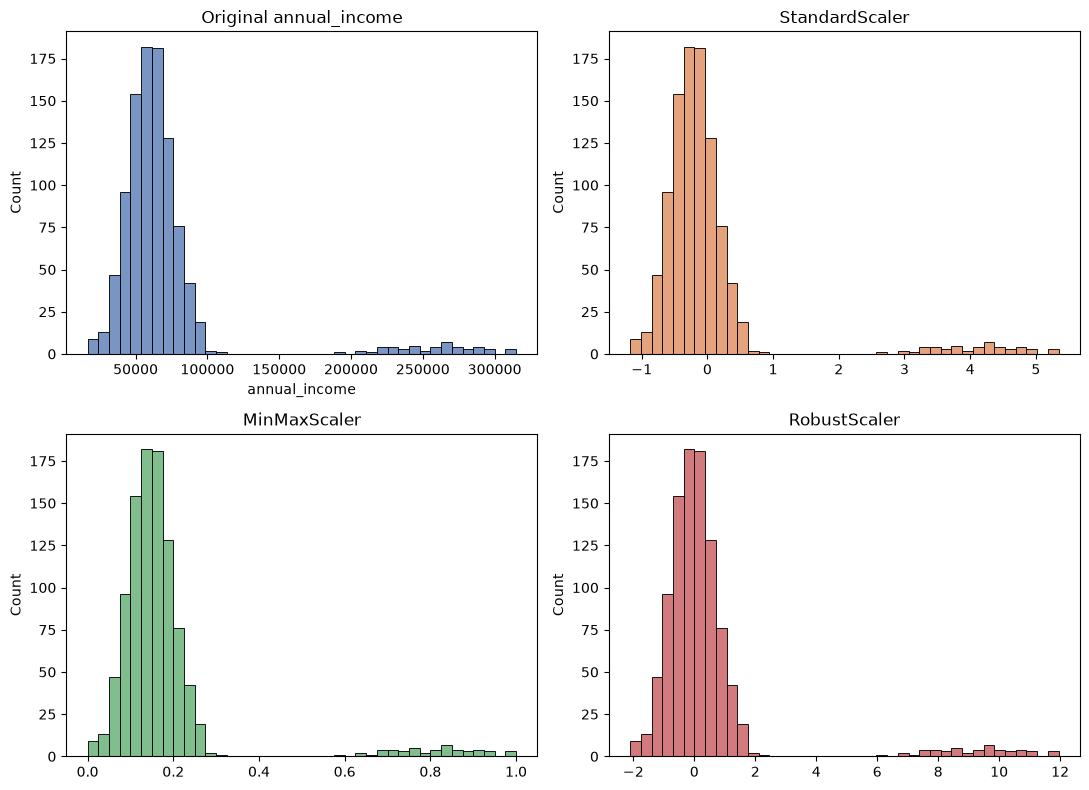

StandardScaler range: -1.18 to 5.35
MinMaxScaler range: 0.0 to 1.0
RobustScaler range: -2.11 to 11.95


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

income = df[['annual_income']]

std_scaled = StandardScaler().fit_transform(income)
minmax_scaled = MinMaxScaler().fit_transform(income)
robust_scaled = RobustScaler().fit_transform(income)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(income['annual_income'], bins=40, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Original annual_income')
sns.histplot(std_scaled.ravel(), bins=40, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('StandardScaler')
sns.histplot(minmax_scaled.ravel(), bins=40, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('MinMaxScaler')
sns.histplot(robust_scaled.ravel(), bins=40, ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('RobustScaler')
plt.tight_layout()
plt.show()

print("StandardScaler range:", std_scaled.min().round(2), "to", std_scaled.max().round(2))
print("MinMaxScaler range:", minmax_scaled.min().round(2), "to", minmax_scaled.max().round(2))
print("RobustScaler range:", robust_scaled.min().round(2), "to", robust_scaled.max().round(2))

The shape of the histogram doesn't change between any of the four panels — scaling never changes the *shape* of a distribution, only the units on the x-axis. That's worth internalizing: if your data is skewed before scaling, it's still skewed after. Scaling fixes "the numbers are on wildly different scales across columns" (e.g., age in tens, income in tens of thousands); it does not fix skew, and it does not remove outliers.

Look at what differs: `MinMaxScaler`'s panel squeezes the bulk of normal incomes into roughly 0.0–0.3, because the 50 high earners stretch the range all the way to 1.0, and everyone else gets compressed into the leftover space near zero. That's the textbook failure mode for `MinMaxScaler` with outliers present.

`RobustScaler`'s range, -2.11 to 11.95, looks wide, but notice that's because the genuine outliers are still far from the median in IQR units — `RobustScaler` doesn't hide outliers, it just doesn't let them distort the scale for the *non-outlier* majority of the data the way `MinMaxScaler` does. The bulk of the distribution near the median sits in a much more reasonable range than the MinMax version.

**Common mistake:** reaching for `StandardScaler` by default on every numeric column without checking for skew or outliers first — it's the most commonly used scaler, but "most common" and "right for this column" aren't the same thing. Section 1's `.describe()` output, where mean and median diverge, is exactly the signal that should make you reach for `RobustScaler` instead.

**Reflection:** for `customer_age`, which had a mean and median that were very close to each other in Section 1, would you expect `StandardScaler` and `RobustScaler` to produce meaningfully different results? Why or why not?

## Section 5: Demonstrating Data Leakage

This section builds two pipelines: one that fits preprocessing on the full dataset before splitting (the leaky version), and one that splits first and fits only on training data (the correct version).

A heads-up before the numbers: in this dataset, `is_returned` was generated as pure random noise (`np.random.binomial(1, 0.15, n)`), completely unrelated to any feature. That was a deliberate choice for Sections 1–4, so the encoding and scaling examples wouldn't be confused by an underlying "real" pattern. But it means something specific for the leakage demo: there's no actual signal for any model to find, so the leaky version and the correct version below land at nearly identical, close-to-chance AUC. That's not a failed experiment, it's the expected result, and it teaches something real: scaling/encoding leakage, on its own, with a linear model, often produces a small effect, because operations like centering and rescaling are smooth and don't change the rank-ordering of predictions much. It is leakage, and it's still wrong to do, but it's not always the dramatic AUC swing that tutorials sometimes imply.

To show leakage that actually moves a metric a lot, the second half of this section adds a separate, clearly-labeled experiment using feature selection on a synthetic noise dataset, which is the classic textbook case where leakage causes severe, visible overfitting.

### Pipeline A (incorrect): fit on everything, then split

In [18]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

num_cols = ["customer_age", "annual_income", "purchase_amount"]
nominal_cols = ["product_category", "region"]
size_order = [['S', 'M', 'L', 'XL']]

X_full = X.copy()

# Fit encoders and scaler on the FULL dataset, before any split
oe = OrdinalEncoder(categories=size_order)
X_full['size_enc'] = oe.fit_transform(X_full[['size']])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_arr = ohe.fit_transform(X_full[nominal_cols])
ohe_df = pd.DataFrame(ohe_arr, columns=ohe.get_feature_names_out(), index=X_full.index)

scaler = StandardScaler()
scaled_arr = scaler.fit_transform(X_full[num_cols])
scaled_df = pd.DataFrame(scaled_arr, columns=num_cols, index=X_full.index)

X_leaky_final = pd.concat([scaled_df, X_full[['size_enc']], ohe_df], axis=1)

# Only NOW do we split -- the scaler and encoders already "saw" what will become the test set
Xtr_leak, Xte_leak, ytr_leak, yte_leak = train_test_split(
    X_leaky_final, y, test_size=0.2, random_state=42, stratify=y
)

model_a = LogisticRegression(max_iter=1000)
model_a.fit(Xtr_leak, ytr_leak)
pred_a = model_a.predict_proba(Xte_leak)[:, 1]
auc_a = roc_auc_score(yte_leak, pred_a)
print("Pipeline A (leaky) AUC:", round(auc_a, 4))

Pipeline A (leaky) AUC: 0.3562


### Pipeline B (correct): split first, fit only on training data

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("size_ord", OrdinalEncoder(categories=size_order), ["size"]),
    ("nominal_ohe", OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ("income_robust", RobustScaler(), ["annual_income"]),
    ("std_scale", StandardScaler(), ["customer_age", "purchase_amount"]),
])

pipe_b = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# fit() here only ever touches X_train, y_train
pipe_b.fit(X_train, y_train)
pred_b = pipe_b.predict_proba(X_test)[:, 1]
auc_b = roc_auc_score(y_test, pred_b)
print("Pipeline B (correct) AUC:", round(auc_b, 4))
print("Difference (A - B):", round(auc_a - auc_b, 4))

Pipeline B (correct) AUC: 0.3569
Difference (A - B): -0.0008


Both pipelines land around 0.35–0.36 AUC, which is actually *below* 0.5 — worse than a coin flip in terms of ranking. That's consistent with a model trying to find structure in pure noise: there's nothing there, so the specific train/test split makes the "best" achievable AUC bounce around 0.5 somewhat arbitrarily, and small numeric differences between runs come from which exact rows ended up in each split, not from genuine signal.

**The difference between A and B here is tiny** (a swing of -0.0008, which is noise-level). **This is the honest result, and it's worth sitting with rather than papering over with a fabricated dramatic gap.** Two things are both true at once: leaking test-set statistics into a `StandardScaler`/`OneHotEncoder`/`OrdinalEncoder` fit is still incorrect practice and you should never do it, *and* for this particular combination of preprocessing steps and a linear model, the practical damage to AUC can be small or even negligible. Why? `StandardScaler` and `RobustScaler` apply an affine transform (multiply and shift); `LogisticRegression` learns weights that adapt to whatever scale it's handed. Shifting where "zero" sits or rescaling the units doesn't change the relative ordering of predictions much for a model that's already adjusting its coefficients to fit. The leakage is real (test statistics did influence the transform applied to training data), but its *consequence* for this metric, on this kind of preprocessing, with this kind of model, is modest.

**When does leakage swing AUC dramatically?** When the leaking step is itself doing something selective or informative, not just a smooth rescale. The classic case is feature selection done before splitting: picking the "best" features using a process that's allowed to peek at the test labels. Let's see that, on a deliberately constructed example, so the contrast is honest rather than implied.

### A leakage case where the gap is real and large: feature selection before splitting

This uses a separate, synthetic example: 200 purely random noise columns and a target that's also purely random noise (so genuinely, there's nothing to learn — just like our actual `is_returned`). The leaky version picks the "top 10" features most correlated with the target *using the full dataset, test rows included*, then splits. The correct version splits first and only ever looks at training rows when deciding which features look promising.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

np.random.seed(42)
n_demo = 1000
y_demo = np.random.binomial(1, 0.15, n_demo)  # noise target, same setup as is_returned
X_demo = pd.DataFrame(np.random.normal(0, 1, (n_demo, 200)), columns=[f'f{i}' for i in range(200)])

# LEAKY: select the 10 features most correlated with y using the FULL dataset
selector_leak = SelectKBest(score_func=f_classif, k=10).fit(X_demo, y_demo)
X_sel_leak = selector_leak.transform(X_demo)
Xtr, Xte, ytr, yte = train_test_split(X_sel_leak, y_demo, test_size=0.2, random_state=42, stratify=y_demo)
scaler_demo = StandardScaler().fit(Xtr)
m_leak = LogisticRegression(max_iter=1000).fit(scaler_demo.transform(Xtr), ytr)
auc_leak_demo = roc_auc_score(yte, m_leak.predict_proba(scaler_demo.transform(Xte))[:, 1])

# CORRECT: split first, then select features using only the training fold
Xtr2, Xte2, ytr2, yte2 = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42, stratify=y_demo)
selector_ok = SelectKBest(score_func=f_classif, k=10).fit(Xtr2, ytr2)
Xtr2_sel, Xte2_sel = selector_ok.transform(Xtr2), selector_ok.transform(Xte2)
scaler_ok = StandardScaler().fit(Xtr2_sel)
m_ok = LogisticRegression(max_iter=1000).fit(scaler_ok.transform(Xtr2_sel), ytr2)
auc_ok_demo = roc_auc_score(yte2, m_ok.predict_proba(scaler_ok.transform(Xte2_sel))[:, 1])

print("Leaky AUC (features selected using full data, including test rows):", round(auc_leak_demo, 4))
print("Correct AUC (features selected using train rows only):", round(auc_ok_demo, 4))

Leaky AUC (features selected using full data, including test rows): 0.665
Correct AUC (features selected using train rows only): 0.5037


This is the dramatic version: 0.665 vs 0.504, on a target that is, again, pure noise. The leaky pipeline looks like it found real signal (0.665 is well above the 0.5 you'd get from random guessing) but it didn't — it cheated by choosing, out of 200 random columns, the ones that happened to correlate with the test labels purely by chance, because it was allowed to look at the test labels during feature selection. The "correct" version, denied that peek, lands right where it should: 0.5037, indistinguishable from chance.

**Interpretation guidance, in general:**

If the leaky-vs-correct AUC difference is small (like our retail-data example, a ~0.001 gap), the type of leakage you introduced probably involves smooth, non-selective transforms (scaling, simple encoding) on a model that adapts to whatever scale it's given. Still wrong to do, low practical damage in this specific case.

If the difference is large (like the feature-selection example, a 0.16 gap), the leakage involved a step that *selected or learned something specific* using test information — feature selection, hyperparameter tuning via test performance, or any step where the test set's labels directly influenced a choice. This is the more dangerous and more common real-world failure mode, and it's exactly why cross-validation pipelines need to redo feature selection inside each fold, not once on the whole dataset beforehand.

**Common mistake:** assuming "my leaky and correct AUCs are basically the same" means leakage is fine to ignore. It might mean your specific leakage source has a small effect for your specific model and metric — it does not mean leakage in general is harmless. Feature selection, target encoding using global category statistics, and PCA fit on full data are all leakage sources with much bigger blast radii than a `StandardScaler`.

**Reflection:** why did the feature-selection leakage produce such a larger AUC gap than the scaling/encoding leakage did, even though both involve "fitting on data that includes the test set"?

## Section 6: Building a Production Workflow

Sections 2–5 built each preprocessing step by hand, partly so you could see what each one does in isolation. In practice, you don't want to repeat that hand-assembly every time you retrain or deploy — that's what `ColumnTransformer` and `Pipeline` are for. They bundle every preprocessing step plus the model into one object that can be fit, transformed, saved, and reloaded as a single unit.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression

size_order = [['S', 'M', 'L', 'XL']]
nominal_cols = ['product_category', 'region']

preprocessor = ColumnTransformer(transformers=[
    ("size_ord", OrdinalEncoder(categories=size_order), ["size"]),
    ("nominal_ohe", OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ("income_robust", RobustScaler(), ["annual_income"]),
    ("std_scale", StandardScaler(), ["customer_age", "purchase_amount"]),
])

full_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

full_pipeline.fit(X_train, y_train)
preds = full_pipeline.predict_proba(X_test)[:, 1]
auc_pipeline = roc_auc_score(y_test, preds)
print("Production pipeline AUC:", round(auc_pipeline, 4))

Production pipeline AUC: 0.3569


This matches Pipeline B's AUC from Section 5 (0.3569), which it should — it's the same logic, just wrapped into a `ColumnTransformer`/`Pipeline` instead of hand-coded transform calls.

**Why pipelines prevent leakage almost by construction:** when you call `full_pipeline.fit(X_train, y_train)`, every transformer inside the `ColumnTransformer` only ever calls `.fit()` on `X_train`. When you later call `full_pipeline.predict_proba(X_test)`, it calls `.transform()` (not `.fit_transform()`) on the test data, reusing statistics learned from training only. The leaky pattern from Section 5 required *manually* fitting a scaler on the full dataset before splitting — a `Pipeline` structurally makes that mistake harder to make, because there's no full-dataset DataFrame floating around to accidentally call `.fit()` on once you're working through the pipeline object.

**Why pipelines simplify deployment:** at inference time, you don't need to remember "first ordinal-encode size, then one-hot the other two, then robust-scale income, then standard-scale age and purchase amount, in that specific order, using these specific fitted parameters." You call `pipeline.predict()` on raw new data and every step happens automatically, in the right order, with the right fitted parameters.

**Why pipelines improve reproducibility:** the entire preprocessing-plus-model logic is one Python object. Save it, and you've saved every fitted parameter (every scaler's mean/std, every encoder's category list, every model coefficient) in one place. Anyone loading that file gets the exact same transformations, with no risk of accidentally using a slightly different scaler version or order of operations.

**Common mistake:** building a `ColumnTransformer` but still calling `.fit_transform()` on the full `X` (not `X_train`) before passing it into model training — wrapping things in a pipeline doesn't protect you if you still feed it the wrong data.

## Section 7: Saving Artifacts

A fitted pipeline is only useful if you can reload it later, without retraining, and get identical behavior. `joblib` is the standard tool for this in the scikit-learn ecosystem (it handles NumPy arrays more efficiently than the generic `pickle` module).

In [22]:
import joblib

# Save the entire fitted pipeline (preprocessing + model, as one object)
joblib.dump(full_pipeline, "full_pipeline.joblib")

# You can also save individual fitted pieces if you need them separately,
# e.g. to inspect an encoder's learned categories without loading the whole model
joblib.dump(full_pipeline.named_steps['preprocessing'], "preprocessor.joblib")

print("Saved: full_pipeline.joblib, preprocessor.joblib")

Saved: full_pipeline.joblib, preprocessor.joblib


In [23]:
# Reload and verify it produces identical predictions
reloaded_pipeline = joblib.load("full_pipeline.joblib")
reloaded_preds = reloaded_pipeline.predict_proba(X_test)[:, 1]

print("Reloaded predictions match original exactly:", np.allclose(preds, reloaded_preds))

Reloaded predictions match original exactly: True


**Why fitted transformers must be saved, not just the code that created them:** a `StandardScaler` object, once fit, holds specific learned numbers — the training data's mean and standard deviation for each column. If you save only the *code* (`StandardScaler()`) and re-run it on new data later, you get a *new* scaler fit on whatever data happens to be available at that moment, with different means and standard deviations. Predictions made with that new scaler are not consistent with the model you originally trained, even if the model weights themselves are unchanged. The fitted object, with its learned parameters baked in, is what needs to persist.

**What would happen if new transformers were fitted during inference:** imagine a deployed model that, instead of loading a saved scaler, calls `StandardScaler().fit_transform()` fresh on every incoming batch of new data. Two problems show up immediately. First, if that batch is small (say, a single customer's data at prediction time), there's no meaningful mean or standard deviation to compute from one row, the scaler would be fitting to a sample size of one. Second, even with a reasonably sized batch, the mean and standard deviation of new production data will drift from training data over time, so the model receives inputs scaled differently from what it learned on, silently degrading predictions in a way that's hard to debug because nothing crashes, the numbers are just wrong.

**Common mistake:** saving the model (`LogisticRegression` object) but forgetting to save the preprocessing pipeline that feeds it, then trying to reconstruct preprocessing from memory months later and getting it subtly wrong (wrong category order, wrong scaler type, missing a `handle_unknown='ignore'`).

## Section 8: Final Deliverables

### 1. Preprocessing summary table

| Feature | Encoding | Scaling | Reason |
|---|---|---|---|
| `customer_age` | — (already numeric) | StandardScaler | Roughly symmetric distribution, mean ≈ median in Section 1, no outlier concerns |
| `annual_income` | — (already numeric) | RobustScaler | Heavy outliers (50 high-earner rows); median/IQR resist their influence, mean/std don't |
| `purchase_amount` | — (already numeric) | StandardScaler | Right-skewed but no extreme outlier subset like income has; kept simple for this pipeline (see Stretch Challenges for a comparison) |
| `product_category` | OneHotEncoder | — | Nominal, 5 categories, no inherent order |
| `size` | OrdinalEncoder (explicit order) | — | Genuinely ordinal: S < M < L < XL |
| `region` | OneHotEncoder | — | Nominal, 4 categories, no inherent order |

### 2. AUC comparison table

| Workflow | AUC | Leakage? |
|---|---|---|
| Pipeline A — preprocessing fit on full dataset before split | 0.3562 | Yes (scaling + encoding leakage) |
| Pipeline B — preprocessing fit on training data only | 0.3569 | No |
| Production `Pipeline` object (Section 6) | 0.3569 | No |
| Feature-selection demo, leaky (Section 5, synthetic noise data) | 0.6650 | Yes (feature-selection leakage) |
| Feature-selection demo, correct (Section 5, synthetic noise data) | 0.5037 | No |

Both retail-data AUCs sit below 0.5, consistent with `is_returned` being unrelated noise in this synthetic dataset — there was nothing to predict, so don't read "0.3569" as "the model is bad," read it as "there was no signal to find, and the small gap between leaky and correct confirms scaling/encoding leakage had a negligible effect here specifically."

### 3. Preprocessing decision log

`customer_age`: kept as-is, scaled with StandardScaler. No missing values, no extreme outliers, no encoding needed since it's already numeric.

`annual_income`: scaled with RobustScaler instead of StandardScaler, specifically because of the 50-row outlier cluster identified in Section 1 (mean 70,399 vs median 61,266, max over 4x the 75th percentile).

`purchase_amount`: scaled with StandardScaler for this pipeline, despite right-skew (skewness ≈ 1.83), as a deliberate simplification; the Stretch Challenges section below revisits this choice.

`product_category`, `region`: one-hot encoded. Confirmed nominal in Section 2 by checking whether any meaningful order existed (none did); avoided `OrdinalEncoder`'s default alphabetical-order trap.

`size`: ordinal encoded with an explicit category order `[S, M, L, XL]`, rather than relying on `OrdinalEncoder`'s alphabetical default (which would have produced the wrong order: L, M, S, XL).

`is_returned`: kept as the target, untouched by feature preprocessing. Confirmed via `.corr()` that it's uncorrelated with every numeric feature (all correlations under 0.03 in absolute value), consistent with how it was generated.

Train/test split: 80/20, `stratify=y` used throughout because of the 85/15 class imbalance, `random_state=42` fixed for reproducibility across all pipeline variants compared in this notebook.

## Section 9: Reflection Questions, Answered

**1. Why is fitting StandardScaler before splitting considered leakage?**

`StandardScaler.fit()` computes a mean and standard deviation from whatever data it's given. If that data includes rows that will later become the test set, the mean and std used to transform the *training* data were computed partly from test rows. The training data's representation, after transformation, now carries a faint signature of the test set, information the model shouldn't have had access to at training time. It's leakage even though the test set's *labels* (`y`) were never directly used; the leak is in the feature statistics, not necessarily the target.

**2. What information leaks into the test set?**

More precisely: information leaks *from* the test set *into* how the training data gets transformed. Concretely, for scaling: the test set's contribution to the overall mean/std. For one-hot encoding: the test set's contribution to "which categories exist" (so the encoder never has to handle an unseen category, which it would in a true production setting). For imputation: the test set's contribution to whatever statistic fills missing values. The common thread is any statistic computed using `.fit()` on a dataset that includes rows the model will later be evaluated on.

**3. Why can LabelEncoder create problems for feature columns?**

`LabelEncoder` assigns integers to categories with no awareness that those integers might be naively used as ordered/continuous input ("Sports"=4 looking four units away from "Books"=0). Section 2's demonstration showed this exact failure with `OrdinalEncoder` defaulting to alphabetical order on a nominal column; `LabelEncoder` has the identical underlying issue for the same reason; it produces integer codes, and integer codes imply order to most models, whether or not order was intended. It's built for `y`, a single column of class labels where this concern doesn't apply the same way (the model isn't trying to learn from a numeric *relationship* between class 0 and class 1, it's just predicting which class).

**4. Why might OneHotEncoder perform poorly with 200 unique categories?**

Each unique category becomes its own column. With 200 categories, you've added 200 mostly-zero columns to your dataset, which: increases dimensionality a lot relative to your row count (risking overfitting, especially with a small dataset), creates extreme sparsity (most rows are zero in most of these 200 columns, so each individual category might appear only a handful of times in the training set, giving the model very little data to learn a reliable weight for it), and makes the model slower to train and more memory-intensive. The fix is usually a different encoding strategy for high-cardinality columns, covered in the Stretch Challenges below.

**5. When is RobustScaler preferable to StandardScaler?**

When a column has outliers severe enough that the mean and standard deviation (which `StandardScaler` relies on) are themselves distorted by those outliers, the way `annual_income`'s mean was pulled up to 70,399 by 50 high earners despite a median of only 61,266 (Section 1). `RobustScaler`'s median/IQR basis stays stable in that situation, so the bulk of "normal" values get scaled sensibly instead of getting compressed by the outliers' influence on the scaling statistics.

**6. What happens when MinMaxScaler encounters values outside the training range?**

`MinMaxScaler` learns `min` and `max` from the training data and maps that range to [0, 1] (or whatever range you specify). If a new value at inference time falls below the training min or above the training max, the transformed value falls outside [0, 1] — below 0 or above 1. This isn't necessarily catastrophic (the underlying math still works, it just extrapolates linearly), but it does mean the model is now seeing inputs in a range it never encountered during training, which can degrade predictions in ways that are easy to miss if you're not specifically checking for out-of-range values in production data.

## Section 10: Stretch Challenges

These are intentionally left as exercises rather than fully worked solutions, so you can practice the workflow yourself. Starting points for each:

**Add a high-cardinality categorical column with 200 unique values.** Try `df['customer_id_bucket'] = np.random.choice([f'C{i}' for i in range(200)], n)`, then one-hot encode it and check `X_train.shape` before and after, to see the dimensionality explosion directly.

**Compare OneHotEncoder vs TargetEncoder.** `category_encoders` (a separate package, `pip install category_encoders`) or scikit-learn's own `TargetEncoder` (added in recent versions) replace each category with a statistic of the target computed from training data, avoiding the dimensionality blowup of one-hot encoding for high-cardinality columns. Important: target encoders *must* be fit only on training data, since they directly use `y`, making them an even easier way to introduce leakage if you're not careful, this connects directly back to Section 5.

**Compare LogisticRegression performance with each scaler.** Swap `RobustScaler` for `StandardScaler` and `MinMaxScaler` on `annual_income` specifically, keeping everything else in the pipeline fixed, and compare resulting AUCs. Given that `is_returned` is noise in this dataset, expect the differences to be small and largely driven by which random split you happen to get; this exercise is more about practicing the comparison workflow than expecting a dramatic result here.

**Replace RobustScaler with StandardScaler and analyze results.** A direct, single-column version of the above: refit the Section 6 pipeline with `StandardScaler` on `annual_income` instead of `RobustScaler`, and inspect how differently the same raw income values get transformed (the 50 outlier rows will land much further from the bulk of the distribution than they did with `RobustScaler`).

**Introduce missing values and handle them correctly.** Randomly null out part of a column (`df.loc[df.sample(frac=0.1).index, 'annual_income'] = np.nan`), then build an imputation step into the `ColumnTransformer` using `SimpleImputer`, making sure — per Section 3 — that the imputer's `.fit()` only ever touches training data, never the full dataset before splitting.